# SyntheMol

This notebook reproduces the results of the paper: *Generative AI for designing and validating easily synthesizable and structurally novel antibiotics*, Swanson K., Liu G., Catacutan D.B., Arnold A., Zou J., Stokes J.M.,  Nature Machine Intelligence 6, 338–353 (2024).

https://doi.org/10.1038/s42256-024-00809-7

The paper introduces SyntheMol, a generative AI pipeline designed to create structurally novel and easily synthesizable antibiotics to target multidrug-resistant bacteria. Researchers experimentally tested 58 AI-generated molecules against *Acinetobacter baumannii*, finding 6 molecules with activity against both standard and multi-resistant strains. These findings highlight the potential of AI to accelerate antibiotic discovery.

The model pipeline includes the following steps:
* step 1: Prepare the training dataset
* step 2: Train Predictive models to predict antibacterial activity
* step 3: Precompute the predicted scores on the generative model building blocks
* step 4: Generate molecules using a Monte Carlo Tree Search (MCTS) algorithm
* step 5: Filter the generated molecules based on Novelty, bioactivity, and diversity.
* step 6: Predict toxicity of the generated molecules



# Step 0: Setup

In [2]:
# Mount Google Drive to save results
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/MSc_Thesis/Antibiotics/SyntheMol/SyntheMol

/content/drive/MyDrive/MSc_Thesis/Antibiotics/SyntheMol/SyntheMol


In [ ]:
# Clone the repository
!git clone https://github.com/swansonk14/SyntheMol.git
%cd SyntheMol



fatal: destination path 'SyntheMol' already exists and is not an empty directory.
/content/drive/MyDrive/MSc_Thesis/Antibiotics/SyntheMol/SyntheMol


In [ ]:
!pip install -e .

Obtaining file:///content/drive/MyDrive/MSc_Thesis/Antibiotics/SyntheMol/SyntheMol
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.6/166.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Step1: Training data

The training dataset consists of three libraries of compounds:
* Library 1 consists of 2,371 molecules from the Pharmakon-1760 library (1,360
Food and Drug Administration (FDA)-approved drugs and 400 internationally
approved drugs) and from a set of 800 natural products
isolated from plant, animal and microbial sources.
* Library 2 is the
Broad Drug Repurposing Hub with 6,680 molecules, many of which
are FDA-approved drugs or clinical trial candidates.
* Library 3 is a synthetic
small-molecule screening collection with 5,376 molecules, which
were randomly sampled from a larger chemical library at the Broad
Institute.

All three libraries were screened in two biological replicates
against A. baumannii ATCC 17978 for growth inhibitory activity.

**Training dataset preprocessing:**

For each library separately:
* the average normalized
OD600 was computed for each compound from the two biological replicates.
* the mean $\mu$ and standard deviation $\sigma$ of these average
normalized OD600 values were computed across the compounds of the library.
* values were binarized, using the threshold $\mu - 2 \sigma$ : all values below
the threshold were labelled active and all values at or above this threshold
labelled inactive.
* the SMILES were canonicalized using RDKit *Chem.MolToSmiles()* and *Chem.MolFromSmiles()* functions to ensure that a unique Smiles representation was used for the same molecule.
More specifically, RDKit Chem.MolFromSmiles(smiles) converts the SMILES string into a RDKit molecule object m. Then Chem.MolToSmiles(m) converts the RDKit molecule m back into a canonicalized SMILES string.
        

The three libraries were combined into a single dataset with 14,427 data points. In this combined dataset, for any data points with matching SMILES and binary activity labels, only one data point was kept, resulting in 13,594 data
points. Any data points with matching SMILES and conflicting
binary activity values was removed to avoid noisy activity labels.
The final dataset has 13,524 unique molecules, of which:
 * 470 (3.5%) are active and
 * 13,054 (96.5%) are inactive.

In [ ]:
%cd /content/drive/MyDrive/MSc_Thesis/Antibiotics/SyntheMol/SyntheMol
!python scripts/data/process_data.py \
    --data_paths data/Data/1_training_data/library_1.csv data/Data/1_training_data/library_2.csv data/Data/1_training_data/library_3.csv \
    --save_path data/Data/1_training_data/antibioticsCR.csv \
    --save_hits_path data/Data/1_training_data/antibiotics_hitsCR.csv \
    --activity_column antibiotic_activity

/content/drive/MyDrive/MSc_Thesis/Antibiotics/SyntheMol/SyntheMol
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
library_1
Data size = 2,371
Mean activity = 0.9759337199493885
Std activity = 0.26737718213375383
Activity threshold of mean - 2 std = 0.4411793556818808
Number of hits = 130
Number of non-hits = 2,241

library_2
Data size = 6,680
Mean activity = 0.9701813713618264
Std activity = 0.17623388953330246
Activity threshold of mean - 2 std = 0.6177135922952215
Number of hits = 294
Number of non-hits = 6,386

library_3
Data size = 5,376
Mean activity = 0.9980530249561013
Std activity = 0.13303517604919068
Activity threshold of mean - 2 std = 0.7319826728577199
Number of hits = 112
N

In [ ]:
# original paper training dataset
import pandas as pd
%cd /content/drive/MyDrive/MSc_Thesis/Antibiotics/SyntheMol/SyntheMol
# load original training data from antibiotics.csv
data = pd.read_csv("data/Data/1_training_data/antibiotics.csv")

# Show number of compounds, hits
activity_column = 'antibiotic_activity'

print(f'Final data size = {len(data):,}')
print(f'Number of hits = {sum(data[activity_column] == 1):,}')
print(f'Number of non-hits = {sum(data[activity_column] == 0):,}')


/content/drive/MyDrive/MSc_Thesis/Antibiotics/SyntheMol/SyntheMol
Final data size = 13,524
Number of hits = 470
Number of non-hits = 13,054


In [ ]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: True


# Step 2: Train the Bioactivity Prediction Models


3 prediction models were used to predict the antibiotic activity of the generated compounds:

* **Chemprop:** A Message Passing Graph Neural Network (MP-GNN) implemented in the paper: *Analyzing learned molecular representations for
property prediction.*,  Yang, K. et al. , J. Chem. Inf. Model. 59, 3370-3388 (2019). https://arxiv.org/abs/1904.01561

https://github.com/chemprop/chemprop

* **Chemprop + RDKit:** a variant of Chemprop model that incorporates a set
of 200 molecular features computed by the cheminformatics package
RDKit.

* **Random Forest:** A Random Forest model with 100 decision trees, using the 200 RDKit molecular features as input to predict antibacterial activity.

All three models were trained using tenfold cross-validation with splits containing 80% train, 10% validation and 10% test data.

## 2.1 Chemprop

**Chemprop**
(Version used: Chemprop v.1.5.2 with PyTorch v.1.12.0.post2)

Chemprop is a molecular property prediction model that
uses a directed message passing neural network (MPNN) to process molecules
and make predictions about their molecular properties.

Chemprop's architecture follows the following steps:
* extracts simple atom and bond features from the molecular graph,
such as the type of each atom and the type of each bond, to create a
feature vector for each atom and bond.

* applies three message passing steps, which use a neural network layer to iteratively merge information from neighbouring atoms and bonds.

* sums all the merged feature vectors to create a single feature vector that represents the whole molecule.

* This feature vector is passed through a feed-forward neural network
with two layers to predict the molecular property (here : the probability of *A. baumannii* growth inhibition).


In [ ]:
import pandas as pd

# Train Chemprop model
!python scripts/models/train.py \
    --data_path data/Data/1_training_data/antibiotics.csv \
    --save_dir data/Models/antibiotic_chemprop \
    --dataset_type classification \
    --model_type chemprop \
    --property_column antibiotic_activity \
    --num_models 10 \



Streaming output truncated to the last 5000 lines.

  5% 11/217 [00:01<00:22,  9.09it/s]

  6% 12/217 [00:01<00:22,  9.23it/s]

  6% 14/217 [00:01<00:21,  9.64it/s]

  7% 15/217 [00:01<00:21,  9.20it/s]

  7% 16/217 [00:03<01:35,  2.11it/s]

  8% 17/217 [00:03<01:15,  2.65it/s]Loss = 3.8619e-02, PNorm = 44.3999, GNorm = 0.1029, lr_0 = 3.1204e-04


  9% 19/217 [00:03<00:50,  3.90it/s]

  9% 20/217 [00:03<00:43,  4.49it/s]

 10% 21/217 [00:03<00:37,  5.20it/s]

 11% 23/217 [00:03<00:29,  6.60it/s]

 12% 25/217 [00:04<00:25,  7.60it/s]

 12% 26/217 [00:04<00:24,  7.86it/s]Loss = 6.3577e-02, PNorm = 44.4125, GNorm = 0.8373, lr_0 = 3.1086e-04


 13% 28/217 [00:04<00:22,  8.56it/s]

 13% 29/217 [00:04<00:21,  8.67it/s]

 14% 30/217 [00:04<00:21,  8.86it/s]

 14% 31/217 [00:04<00:20,  8.97it/s]

 15% 32/217 [00:04<00:20,  9.10it/s]

 16% 34/217 [00:05<00:18,  9.78it/s]

 17% 36/217 [00:05<00:18,  9.86it/s]

 17% 37/217 [00:05<00:18,  9.86it/s]Loss = 9.7126e-02, PNorm = 44.4287, GNorm = 0.5382

## 2.2 Chemprop-RDkit

The Chemprop-RDKit model is a variant of the
Chemprop model described in 2.1. This model applies the same message
passing procedure to obtain a single feature vector representing
the molecule, but before applying the two feed-forward neural
network layers, the molecular feature vector from message passing
is concatenated with 200 molecular features computed by RDKit. The concatenated vector
is then used as input to the feed-forward neural network to make the
property prediction.

In [ ]:
!python scripts/models/train.py \
    --data_path data/Data/1_training_data/antibiotics.csv \
    --save_dir data/Models/antibiotic_chemprop_rdkit \
    --model_type chemprop \
    --dataset_type classification \
    --fingerprint_type rdkit \
    --property_column antibiotic_activity \
    --num_models 10

Streaming output truncated to the last 5000 lines.
 58% 125/217 [00:11<00:08, 10.77it/s]

 59% 127/217 [00:12<00:08, 10.13it/s]

 59% 129/217 [00:12<00:08, 10.32it/s]

 60% 131/217 [00:12<00:08,  9.85it/s]

 61% 132/217 [00:12<00:08,  9.86it/s]Loss = 9.3247e-02, PNorm = 42.7545, GNorm = 0.1649, lr_0 = 4.1548e-04


 62% 134/217 [00:12<00:08,  9.72it/s]

 62% 135/217 [00:13<00:08,  9.59it/s]

 63% 137/217 [00:13<00:08,  9.78it/s]

 64% 139/217 [00:13<00:07, 10.22it/s]

 65% 141/217 [00:13<00:07,  9.96it/s]

 65% 142/217 [00:13<00:08,  9.33it/s]

 66% 143/217 [00:13<00:08,  9.17it/s]Loss = 6.6736e-02, PNorm = 42.7865, GNorm = 0.2705, lr_0 = 4.1390e-04


 67% 145/217 [00:14<00:07,  9.85it/s]

 68% 147/217 [00:14<00:07,  9.83it/s]

 69% 149/217 [00:14<00:06,  9.99it/s]

 70% 151/217 [00:14<00:06, 10.07it/s]

 71% 153/217 [00:14<00:06,  9.97it/s]Loss = 9.8133e-02, PNorm = 42.8074, GNorm = 0.2179, lr_0 = 4.1233e-04


 71% 155/217 [00:15<00:06, 10.22it/s]

 72% 157/217 [00:15<00:05, 10.26it/s]

## 2.3 Random Forest

The random forest model takes the molecular graph and computes the
same 200 RDKit features as in the Chemprop-RDKit model. These
200 RDKit features are fed as input to a random forest classifier model
with 100 decision trees, each of which makes a binary classification
prediction. The prediction of the random forest is the average of the
predictions of the decision trees.

The RandomForestClassifier from scikit-learn v.1.1.1 was used, with all default settings besides n_jobs=−1 and random_state=0

In [ ]:
!python scripts/models/train.py \
    --data_path data/Data/1_training_data/antibiotics.csv \
    --save_dir data/Models/antibiotic_random_forest \
    --model_type random_forest \
    --dataset_type classification \
    --fingerprint_type rdkit \
    --property_column antibiotic_activity \
    --num_models 10

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Data size = 13,524
rdkit fingerprints: 100% 13524/13524 [02:06<00:00, 107.04it/s]
cross-val:   0% 0/10 [00:00<?, ?it/s]Model 0
RandomForestClassifier(n_jobs=-1, random_state=0)
Test roc_auc = 0.839
Test prc_auc = 0.421
Test time_seconds = 1.267

cross-val:  10% 1/10 [00:01<00:11,  1.30s/it]Model 1
RandomForestClassifier(n_jobs=-1, random_state=0)
Test roc_auc = 0.836
Test prc_auc = 0.409
Test time_seconds = 1.250

cross-val:  20% 2/10 [00:02<00:10,  1.28s/it]Model 2
RandomForestClassifier(n_jobs=-1, random_state=0)
Test roc_auc = 0.856
Test prc_auc = 0.463
Test time_seconds = 1.386

cross-val:  30% 3/10 [00:03<00:09,  1.34s/it]Model 3
Rando

## predictive models results

Original results from the paper:  

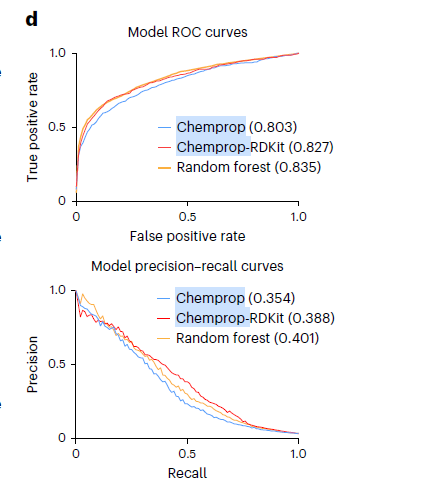

In [ ]:
!python scripts/plot/plot_auc.py \
    --data_dir data/Models/antibiotic_random_forest \
    --save_dir plots/auc \
    --model_name "Random Forest" \
    --curve_type ROC

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.


In [ ]:
# predictive models ROC_AUC, PRC_AUC (reproduced results)
import pandas as pd
# Chemprop
df1 = pd.read_csv('data/Models/antibiotic_chemprop/summary_scores.csv')
print('Chemprop results:\n', df1.iloc[:, :4].to_string(index=False))
# Chemprop-RDKit
df2 = pd.read_csv('data/Models/antibiotic_chemprop_rdkit/summary_scores.csv')
print('Chemprop-RDKit results:\n', df2.iloc[:, :4].to_string(index=False))
# Random Forest
df3 = pd.read_csv('data/Models/antibiotic_random_forest/summary_scores.csv')
print('Random Forest results:\n', df3.iloc[:, :4].to_string(index=False))

Chemprop results:
  roc_auc_mean  roc_auc_std  prc_auc_mean  prc_auc_std
     0.808866     0.027931      0.350374     0.094734
Chemprop-RDKit results:
  roc_auc_mean  roc_auc_std  prc_auc_mean  prc_auc_std
     0.823932     0.028847       0.38434     0.072071
Random Forest results:
  roc_auc_mean  roc_auc_std  prc_auc_mean  prc_auc_std
      0.83561     0.032171      0.400827     0.094937


#Step 3: Pre-compute Building Block Scores


To accelerate the generative model, the predictive model's scores are precomputed for the building blocks, for each predictive model (10 versions for each model, corresponding to each of the 10 fold cross validation train/val/test sets).  

## 3.1 Chemprop

In [ ]:
!python scripts/models/predict.py \
    --data_path data/Data/4_real_space/building_blocks.csv \
    --save_path data/Models/antibiotic_chemprop/building_blocks.csv \
    --model_path data/Models/antibiotic_chemprop \
    --model_type chemprop \
    --average_preds

Streaming output truncated to the last 5000 lines.
 49% 1361/2762 [00:37<00:38, 36.44it/s]
 49% 1365/2762 [00:37<00:37, 36.91it/s]
 50% 1369/2762 [00:37<00:37, 37.10it/s]
 50% 1373/2762 [00:37<00:37, 37.16it/s]
 50% 1377/2762 [00:37<00:38, 36.28it/s]
 50% 1381/2762 [00:37<00:39, 34.96it/s]
 50% 1385/2762 [00:37<00:41, 33.52it/s]
 50% 1389/2762 [00:37<00:40, 33.62it/s]
 50% 1393/2762 [00:37<00:39, 34.94it/s]
 51% 1397/2762 [00:38<00:37, 35.95it/s]
 51% 1401/2762 [00:38<00:38, 35.28it/s]
 51% 1405/2762 [00:38<00:37, 36.10it/s]
 51% 1409/2762 [00:38<00:36, 36.58it/s]
 51% 1413/2762 [00:38<00:38, 35.45it/s]
 51% 1417/2762 [00:38<00:39, 34.18it/s]
 51% 1421/2762 [00:38<00:38, 34.86it/s]
 52% 1425/2762 [00:38<00:38, 34.97it/s]
 52% 1429/2762 [00:38<00:38, 35.07it/s]
 52% 1433/2762 [00:39<00:38, 34.16it/s]
 52% 1437/2762 [00:39<00:38, 34.09it/s]
 52% 1441/2762 [00:39<00:39, 33.58it/s]
 52% 1445/2762 [00:39<00:37, 34.91it/s]
 52% 1449/2762 [00:39<00:38, 34.12it/s]
 53% 1453/2762 [00:39<00:37, 

## 3.2 Chemprop_RDKit

In [ ]:
!python scripts/models/predict.py \
    --data_path data/Data/4_real_space/building_blocks.csv \
    --save_path data/Models/antibiotic_chemprop_rdkit/building_blocks.csv \
    --model_path data/Models/antibiotic_chemprop_rdkit \
    --model_type chemprop \
    --fingerprint_type rdkit \
    --average_preds

Streaming output truncated to the last 5000 lines.
 51% 1405/2762 [00:38<00:38, 35.52it/s]
 51% 1409/2762 [00:38<00:38, 35.55it/s]
 51% 1413/2762 [00:38<00:39, 34.47it/s]
 51% 1417/2762 [00:38<00:40, 33.29it/s]
 51% 1421/2762 [00:39<00:39, 33.79it/s]
 52% 1425/2762 [00:39<00:39, 33.91it/s]
 52% 1429/2762 [00:39<00:39, 34.09it/s]
 52% 1433/2762 [00:39<00:39, 33.76it/s]
 52% 1437/2762 [00:39<00:39, 33.90it/s]
 52% 1441/2762 [00:39<00:39, 33.85it/s]
 52% 1445/2762 [00:39<00:37, 35.01it/s]
 52% 1449/2762 [00:39<00:37, 34.78it/s]
 53% 1453/2762 [00:39<00:38, 34.35it/s]
 53% 1457/2762 [00:40<00:38, 34.14it/s]
 53% 1461/2762 [00:40<00:37, 34.55it/s]
 53% 1465/2762 [00:40<00:37, 34.59it/s]
 53% 1469/2762 [00:40<00:38, 34.02it/s]
 53% 1473/2762 [00:40<00:37, 34.49it/s]
 53% 1477/2762 [00:40<00:37, 33.84it/s]
 54% 1481/2762 [00:40<00:37, 34.44it/s]
 54% 1485/2762 [00:40<00:36, 34.65it/s]
 54% 1489/2762 [00:40<00:36, 34.57it/s]
 54% 1493/2762 [00:41<00:38, 32.71it/s]
 54% 1497/2762 [00:41<00:39, 

## 3.2 Random Forest

In [ ]:
!python scripts/models/predict.py \
    --data_path data/Data/4_real_space/building_blocks.csv \
    --save_path data/Models/antibiotic_random_forest/building_blocks.csv \
    --model_path data/Models/antibiotic_random_forest \
    --model_type random_forest \
    --fingerprint_type rdkit \
    --average_preds

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
rdkit fingerprints: 100% 138060/138060 [14:30<00:00, 158.61it/s]
models: 100% 10/10 [00:02<00:00,  3.94it/s]


# Step 4: Generate Molecules



To generate new molecules with antibacterial activity, the authors implemented SyntheMol, a Monte Carlo Tree Search (MCTS) algorithm that explores a vast combinatorial chemical space of nearly 30 billion molecules, guided by a property prediction model (Chemprop, Chemprop_RDKit or Random Forest). The chemical space is derived from:
* $\approx 132000$ purchasable building blocks
* and 13 validated chemical reactions.

These building blocks and reactions were extracted from the Enamine
REadily AccessibLe (REAL) Space. The REAL Space consists of 31 billion
single-reaction molecules that can be produced by applying 169 chemical
reactions to 138,085 molecular building blocks. In this paper, only the 13 more frequent reactions were kept, and building blocks were filtered for unicity. The resulting chemical space corresponds to 93.7% of the REAL chemical space.

The synthesis tree represents the different synthesis paths that can lead to each of the molecules of the chemical space. Each node contains a list of molecules that can be reactants of one the 13 possible reactions considered in the chemical space. The root of the tree is an empty node. Children nodes can be created by 2 possible ways:
* If a building block can be added to the list of reactants in its parent node, a child node containing this building block is added.
* If the molecules in the parent node can interact together via one of the 13 reactions - and without the need of an additional molecule - then the products of the reaction are added in children nodes.

During each MCTS rollout, SyntheMol constructs a molecule by selecting
building blocks and combining them with chemical reactions.
The generated molecule is then evaluated by a property prediction
model, which provides feedback to the MCTS algorithm, by updating the score of each node in the tree.

SyntheMol balances exploration and exploitation by computing a score
that values both previously unselected building blocks
(exploration) as well as building blocks that are known to lead to
high-scoring molecules (exploitation). The scoring function used in the SyntheMol algo is described below:

**Scoring Functions in SyntheMol**

In the SyntheMol algorithm, each node $N$ in the chemical tree is assigned a score $S(N)$, which is computed as:

$$
S(N) = \frac{Q(N) + P(N) \cdot U(N)}{D(N)}
$$

This score balances four components: **exploitation**, **molecular property prediction**, **exploration**, and **building block diversity**. Each component is defined as follows:

**1. Exploitation Factor $Q(N)$**

The exploitation factor encourages the algorithm to follow routes that lead to high-scoring final molecules. It is calculated as:

$$
Q(N) = \frac{N_{\text{value}}}{N_{\text{visit}}}
$$

where:
- $N_{\text{value}}$ is the sum of property prediction scores of all final molecules discovered during rollouts that visit node $N$.
- $N_{\text{visit}}$ is the number of times node $N$ has been visited.

**2. Property Prediction Factor $P(N)$**

This factor represents the average property prediction score of the molecules in node $N$, encouraging the selection of nodes with high-scoring molecules. It is computed as:

$$
P(N) = \frac{1}{|N_{\text{mols}}|} \sum_{i=1}^{|N_{\text{mols}}|} M(N_{i_{\text{mols}}})
$$

where:
- $N_{\text{mols}}$ is the set of molecules in node $N$,
- $M(N_{i_{\text{mols}}})$ is the property prediction model score for the $i$-th molecule in node $N$.

**3. Exploration Factor $U(N)$**

The exploration factor encourages the algorithm to select child nodes that have not been visited frequently compared to their sibling nodes. It is given by:

$$
U(N) = c \cdot \sqrt{1 + N_{\text{visit}} + \sum_{N' \in N_{\text{siblings}}} \frac{N'_{\text{visit}}}{1 + N_{\text{visit}}}}
$$

where:
- $c = 10$ is a hyperparameter controlling the exploration-exploitation tradeoff,
- $N_{\text{siblings}}$ is the set of sibling nodes of $N$,
- $N'_{\text{visit}}$ is the visit count of a sibling node.

**4. Building Block Diversity Factor $D(N)$**

The building block diversity factor penalizes the algorithm for selecting nodes that contain molecules with building blocks that have already been used many times in previously visited nodes. It is calculated as:

$$
D(N) = e^{\frac{N_{\text{diversity}} - 1}{100}}
$$

where:
- $N_{\text{diversity}}$ is the maximum number of times any building block has been used across all the molecules in $N_{\text{mols}}$ and other previously searched nodes.


After a set
number of rollouts, SyntheMol outputs all the generated compounds
along with the specific synthetic scheme—the building blocks and
chemical reactions in order—required to synthesize each molecule.

## 4.1 Chemprop

As a first step, the MCTS algo was run for 2,000 rollouts only to limit runtime to approx. 1h30 (compared to 8h30 for 20,000 rollouts in the SyntheMol paper).

In [ ]:
!synthemol \
    --model_path data/Models/antibiotic_chemprop \
    --model_type chemprop \
    --building_blocks_path data/Models/antibiotic_chemprop/building_blocks.csv \
    --building_blocks_score_column chemprop_ensemble_preds \
    --building_blocks_id_column Reagent_ID \
    --reaction_to_building_blocks_path data/Data/4_real_space/reaction_to_building_blocks_filtered.pkl \
    --save_dir data/Data/6_generations_chemprop \
    --max_reactions 1 \
    --n_rollout 2000 \
    --replicate

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading building blocks...
Loaded 132,479 building blocks
Found 132,479 unique building blocks
Loading and setting allowed building blocks for each reaction...
Loading models and creating model scoring function...
/usr/local/lib/python3.11/dist-packages/chemprop/utils.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the 

In [ ]:
# Number of generated molecules with chemprop score above 0.5
import pandas as pd
df = pd.read_csv('data/Data/6_generations_chemprop/molecules.csv')
print(df[df['score'] > 0.5].shape)


(1197, 18)


In [ ]:
# compute chemprop predicted activity on molecules.csv
!python scripts/models/predict.py \
    --data_path data/Data/6_generations_chemprop/molecules.csv \
    --save_path data/Data/6_generations_chemprop/molecules_chemprop_preds.csv \
    --model_path data/Models/antibiotic_chemprop \
    --model_type chemprop \
    --average_preds


<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
/usr/local/lib/python3.11/dist-packages/chemprop/utils.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are

In [ ]:
# Number of molecules with chemprop scores above 0.5
df = pd.read_csv('data/Data/6_generations_chemprop/molecules_chemprop_preds.csv')
print(df[df['chemprop_ensemble_preds'] > 0.5].shape)

(1197, 19)


## 4.2 Chemprop-RDKit

In [ ]:
!synthemol \
    --model_path data/Models/antibiotic_chemprop_rdkit \
    --model_type chemprop \
    --building_blocks_path data/Models/antibiotic_chemprop_rdkit/building_blocks.csv \
    --building_blocks_score_column chemprop_rdkit_ensemble_preds \
    --building_blocks_id_column Reagent_ID \
    --reaction_to_building_blocks_path data/Data/4_real_space/reaction_to_building_blocks_filtered.pkl \
    --save_dir data/Data/7_generations_chemprop_rdkit \
    --fingerprint_type rdkit \
    --max_reactions 1 \
    --n_rollout 2000 \
    --replicate



<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading building blocks...
Loaded 132,479 building blocks
Found 132,479 unique building blocks
Loading and setting allowed building blocks for each reaction...
Loading models and creating model scoring function...
/usr/local/lib/python3.11/dist-packages/chemprop/utils.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the 

## 4.3 Random Forest

In [ ]:
!synthemol \
    --model_path data/Models/antibiotic_random_forest \
    --model_type random_forest \
    --building_blocks_path data/Models/antibiotic_random_forest/building_blocks.csv \
    --building_blocks_score_column random_forest_rdkit_ensemble_preds \
    --building_blocks_id_column Reagent_ID \
    --reaction_to_building_blocks_path data/Data/4_real_space/reaction_to_building_blocks_filtered.pkl \
    --save_dir data/Data/8_generations_random_forest \
    --fingerprint_type rdkit \
    --max_reactions 1 \
    --n_rollout 2000 \
    --replicate

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading building blocks...
Loaded 132,479 building blocks
Found 132,479 unique building blocks
Loading and setting allowed building blocks for each reaction...
Loading models and creating model scoring function...
Setting up generator...
Generating molecules...
Running rollouts 1 through 2000...
100% 2000/2000 [2:03:53<00:00,  3.72s/it]
MCTS time = 2:03:53.918485
Number of full molecule, nonzero reaction nodes = 2,894
Approximate total number of nodes searched = 95,111,794
Saving molecules...



# Step 5: Filter Generated Molecules


3 different filters are applied to the generated molecules:
* **Novelty filtering**: the generated molecules are compared to the antibiotics from the training dataset and the antibiotics from the ChEMBL database to select only the most structurally different molecules, based on the **Tversky index** measure of similiarity.

* **Activity filtering**: Keep only the top 20% of the generated molecules, ranked by their model scores (i.e. predicted bioactivity).

* **Diversity filtering**: Filter for diverse molecules by clustering molecules based on their Morgan fingerprint and only keeping the top scoring molecule from each cluster.
    


## 5.1 Novelty Filtering
Compute a measure of similarity between the generated molecules and the antibiotics identified in the training dataset and in the ChEMBL database, and keep only the most dissimilar molecules, defined as molecules with a **Tversky index** $\leq 0.5$.  

The **Tversky index** is defined as:

$$T(A, B) = \frac{|A \cap B|}{|A \cap B| + \alpha |A - B| + \beta |B - A|}$$

where:
* $|A \cap B|$ is the number of elements common to both sets $A$ and $B$.
* $ |A - B| $ is the number of elements in $ A$ but not in $ B $.
* $ |B - A| $ is the number of elements in $ B $ but not in $ A $.
* $\alpha$ and $ \beta $ are weighting parameters controlling the asymmetry of the measure.

When $\alpha = \beta = 1 $, the Tversky index reduces to the **Jaccard index**:
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

In [ ]:
# Novelty Filtering - training set hits
names = [
    "6_generations_chemprop",
    "7_generations_chemprop_rdkit",
    "8_generations_random_forest"
]

for name in names:
  !chemfunc nearest_neighbor \
    --data_path data/Data/{name}/molecules.csv \
    --reference_data_path data/Data/1_training_data/antibiotics_hits.csv \
    --reference_name antibiotics_hits \
    --metric tversky





<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading data
Computing similarities using tversky metric
morgan fingerprints: 100% 2597/2597 [00:00<00:00, 6819.02it/s]
morgan fingerprints: 100% 470/470 [00:00<00:00, 7876.00it/s]
Finding minimum distance SMILES
Saving
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading data
Computing similarities using tversky metric
morgan fingerprints

In [ ]:
# Novelty Filtering - ChEMBL hits
names = [
    "6_generations_chemprop",
    "7_generations_chemprop_rdkit",
    "8_generations_random_forest"
]

for name in names:
  !chemfunc nearest_neighbor \
    --data_path data/Data/{name}/molecules.csv \
    --reference_data_path data/Data/2_chembl/chembl.csv \
    --reference_name chembl \
    --metric tversky



<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading data
Computing similarities using tversky metric
morgan fingerprints: 100% 2597/2597 [00:00<00:00, 7276.12it/s]
morgan fingerprints: 100% 1005/1005 [00:00<00:00, 5378.36it/s]
Finding minimum distance SMILES
Saving
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading data
Computing similarities using tversky metric
morgan fingerprin

In [ ]:

# Novelty Filtering - filter molecules with Tversky index lower than 0.5
names = [
    "6_generations_chemprop",
    "7_generations_chemprop_rdkit",
    "8_generations_random_forest"
]

for name in names:
  !chemfunc filter_molecules \
    --data_path data/Data/{name}/molecules.csv \
    --save_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5.csv \
    --filter_column antibiotics_hits_tversky_nearest_neighbor_similarity \
    --max_value 0.5

for name in names:
  !chemfunc filter_molecules \
    --data_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5.csv \
    --save_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5.csv \
    --filter_column chembl_tversky_nearest_neighbor_similarity \
    --max_value 0.5


<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Original data size = 2,597
Data size after filtering with max_value 0.5 = 1,446
Final data size = 1,446
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Original data size = 2,867
Data size after filtering with max_value 0.5 = 763
Final data size = 763
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr

## 5.2 Bioactivity Filtering

In [ ]:

# Bioactivity Filtering
names = [
    "6_generations_chemprop",
    "7_generations_chemprop_rdkit",
    "8_generations_random_forest"
]
for name in names:
  !chemfunc filter_molecules \
    --data_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5.csv \
    --save_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5_top_20_percent.csv \
    --filter_column score \
    --top_proportion 0.2


<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Original data size = 1,004
Keeping top 201 molecules.
Data size after selecting bottom and/or top molecules = 201
Final data size = 201
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Original data size = 355
Keeping top 71 molecules.
Data size after selecting bottom and/or top molecules = 71
Final data size = 71
<frozen importlib._bootstrap>

## 5.3 Diversity Filtering

In [ ]:
# Group molecules in 50 clusters based on Morgan fingerprint
for name in names:
  !chemfunc cluster_molecules \
    --data_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5_top_20_percent.csv \
    --num_clusters 50

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading data
Data size = 201
Computing Morgan fingerprints
morgan fingerprints: 100% 201/201 [00:00<00:00, 8243.51it/s]
Clustering
Saving data
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Loading data
Data size = 71
Computing Morgan fingerprints
morgan fingerprints: 100% 71/71 [00:00<00:00, 7054.26it/s]
Clustering
Saving data
<frozen impor

In [ ]:
# select the top scoring molecule in each cluster
for name in names:
  !chemfunc select_from_clusters \
    --data_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5_top_20_percent.csv \
    --save_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5_top_20_percent_selected_50.csv \
    --value_column score

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Original data size = 201
Final data size = 50
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
Original data size = 71
Final data size = 50
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstra


## Map selected molecules to REAL ids



In [ ]:
for name in names:
  !python scripts/data/map_generated_molecules_to_real_ids.py \
    --data_path data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5_top_20_percent_selected_50.csv \
    --save_dir data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5_top_20_percent_selected_50_real_ids


Data size = 50
Number of one-reaction molecules = 50
Data size = 50
Number of one-reaction molecules = 50
Data size = 50
Number of one-reaction molecules = 50


Look for the 6 active molecules in the selected candidates (based on 2,000 rollouts)

In [ ]:
names = [
    "6_generations_chemprop",
    "7_generations_chemprop_rdkit",
    "8_generations_random_forest"
]
# look for the 6 active molecules in the selected 50 molecules based on the 2000 rollouts of MCTS
# load the synthetized molecules
df = pd.read_csv('data/Data/9_synthesized/synthesized.csv')
# extract the 6 active molecule (compound_id =  10, 23, 28, 31, 40, 43) from the synthetised
active = df[df['compound_id'].isin([10, 23, 28, 31, 40, 43])]
active.to_csv('data/Data/9_synthesized/active.csv', index=False)
# compare molecules SMILES in each filtered results
for name in names:
  df = pd.read_csv(f'data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5_top_20_percent_selected_50.csv')
  # compare real ids with those in active df
  common_smiles = df[df['smiles'].isin(active['smiles'])]
  print(f"Common active molecules in {name}:")
  print(common_smiles[['smiles']])


Common active molecules in 6_generations_chemprop:
Empty DataFrame
Columns: [smiles]
Index: []
Common active molecules in 7_generations_chemprop_rdkit:
Empty DataFrame
Columns: [smiles]
Index: []
Common active molecules in 8_generations_random_forest:
Empty DataFrame
Columns: [smiles]
Index: []


Look for the 6 active molecules in the selected generated molecules (based on the original paper 20,000 rollouts)

In [ ]:
names = [
    "6_generations_chemprop",
    "7_generations_chemprop_rdkit",
    "8_generations_random_forest"
]
# look for the 6 active molecules in the selected 50 molecules based on the original 20000 rollouts of MCTS
# load the synthetized molecules
df = pd.read_csv('data/Data/9_synthesized/synthesized.csv')
# extract the 6 active molecule (compound_id =  10, 23, 28, 31, 40, 43) from the synthetised
active = df[df['compound_id'].isin([10, 23, 28, 31, 40, 43])]
active.to_csv('data/Data/9_synthesized/active.csv', index=False)
# compare molecules SMILES in each filtered results
for name in names:
  df = pd.read_csv(f'data/Data/{name}/molecules_antibiotics_hits_sim_below_0.5_chembl_sim_below_0.5_top_20_percent_selected_50_original.csv')
  # compare real ids with those in active df
  common_smiles = df[df['smiles'].isin(active['smiles'])]
  print(f"Common active molecules in {name}:")
  print(common_smiles[['smiles']])


Common active molecules in 6_generations_chemprop:
                                        smiles
29  O=S(=O)(c1ccccc1NCc1cc(F)cc(F)c1O)C(F)(F)F
Common active molecules in 7_generations_chemprop_rdkit:
                                           smiles
8             Brc1cccc(CCCNC2CCc3cccc4cccc2c34)c1
12  COc1cccc(C2(NCCCCCCSc3ccccc3OC(C)=O)CCCCC2)c1
27        O=S(=O)(c1cc(F)ccc1NCc1ccccc1O)C(F)(F)F
Common active molecules in 8_generations_random_forest:
                                               smiles
12  O=S(=O)(NC(c1ccc(OC(F)(F)F)cc1)C(F)(F)F)c1cc(C...
24  O=C(Nc1nc2ccc(S(F)(F)(F)(F)F)cc2s1)C(F)(F)c1cc...


# Step 6: Predict Toxicity

A predictive model trained on ClinTox toxicity dataset is used to estimate the toxicity of the generated molecules.

* **ClinTox toxicity dataset**

The dataset includes 1,478 molecules with two binary labels indicating for each molecule:
  * whether the compound FDA approved
  * whether the compound failed clinical trials due to toxicity reasons.

Since the two labels are almost perfectly inversely correlated (lack of
clinical toxicity almost always implies FDA approval and vice versa in
this dataset), only the clinical toxicity label is used for the training dataset.
Based on this label, 112 (7.58%) of the 1,478 molecules are toxic.

* **Toxicity predictive model**

An ensemble of ten Chemprop-RDKit models - using the same model
settings as with the antibacterial prediction model - is trained on the ClinTox toxicity dataset.

The resulting ensemble model is used to predict the toxicity of the generated molecules.

## 6.1 Train predictive model

In [ ]:
# train Chemprop-RDKit on ClinTox dataset

!python scripts/models/train.py \
    --data_path data/Data/1_training_data/clintox.csv \
    --save_dir data/Models/clintox_chemprop_rdkit \
    --model_type chemprop \
    --dataset_type classification \
    --fingerprint_type rdkit \
    --property_column CT_TOX \
    --num_models 10

Streaming output truncated to the last 5000 lines.
 58% 14/24 [00:01<00:00, 11.84it/s]

 67% 16/24 [00:01<00:00, 11.68it/s]

 75% 18/24 [00:01<00:00, 11.87it/s]Loss = 6.5881e-02, PNorm = 37.6479, GNorm = 0.3553, lr_0 = 1.0000e-04


 83% 20/24 [00:01<00:00, 12.11it/s]

 92% 22/24 [00:01<00:00, 11.93it/s]

100% 24/24 [00:02<00:00, 12.45it/s]

                                   

  0% 0/3 [00:00<?, ?it/s]

100% 3/3 [00:00<00:00, 19.90it/s]

                                 
 97% 29/30 [01:05<00:02,  2.23s/it]Epoch 29


  0% 0/24 [00:00<?, ?it/s]

  8% 2/24 [00:00<00:01, 11.49it/s]

 17% 4/24 [00:00<00:01, 11.90it/s]Loss = 8.6721e-02, PNorm = 37.6564, GNorm = 0.2616, lr_0 = 1.0000e-04


 25% 6/24 [00:00<00:01, 11.64it/s]

 33% 8/24 [00:00<00:01, 11.76it/s]

 42% 10/24 [00:00<00:01, 11.72it/s]

 50% 12/24 [00:01<00:01, 11.81it/s]

 58% 14/24 [00:01<00:00, 11.72it/s]Loss = 8.9239e-02, PNorm = 37.6697, GNorm = 1.0409, lr_0 = 1.0000e-04


 67% 16/24 [00:01<00:00, 11.53it/s]

 75% 18/24 [00:01<

In [ ]:
# model ROC-AUC and PRC-AUC
import pandas as pd
df = pd.read_csv('data/Models/clintox_chemprop_rdkit/summary_scores.csv')
print('Toxicity prediction results on the test set: ')
print(df.iloc[:, :4].to_string(index=False))


Toxicity prediction results on the test set: 
 roc_auc_mean  roc_auc_std  prc_auc_mean  prc_auc_std
     0.862229     0.062278      0.478911     0.124151


## 6.2 Predict toxicity of generated molecules

In [ ]:
!python scripts/models/predict.py \
    --data_path data/Data/9_synthesized/synthesized.csv \
    --model_path data/Models/clintox_chemprop_rdkit \
    --model_type chemprop \
    --fingerprint_type rdkit \
    --average_preds

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.
rdkit fingerprints: 100% 58/58 [00:00<00:00, 114.89it/s]
/usr/local/lib/python3.11/dist-packages/chemprop/utils.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no lon

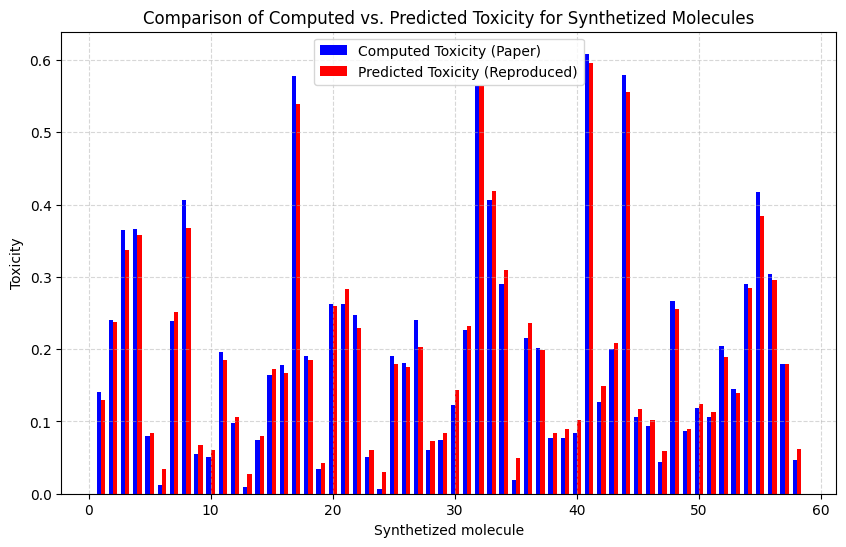

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Plotting the predicted toxicity from the paper versus reproduced

file_path = "data/Data/9_synthesized/synthesized.csv"
df = pd.read_csv(file_path)

paper_toxicity = df["CT_TOX"]
predicted_toxicity = df["chemprop_rdkit_ensemble_preds"]

num_molecules = len(df)
molecule_numbers = np.arange(1, num_molecules + 1)

plt.figure(figsize=(10, 6))

bar_width = 0.35
r1 = molecule_numbers - bar_width / 2
r2 = molecule_numbers + bar_width / 2

plt.bar(r1, paper_toxicity, color='b', width=bar_width, label="Computed Toxicity (Paper)")
plt.bar(r2, predicted_toxicity, color='r', width=bar_width, label="Predicted Toxicity (Reproduced)")

plt.xlabel('Synthetized molecule')
plt.ylabel('Toxicity')
plt.title('Comparison of Computed vs. Predicted Toxicity for Synthetized Molecules')

# Add grid, legend and show the plot
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


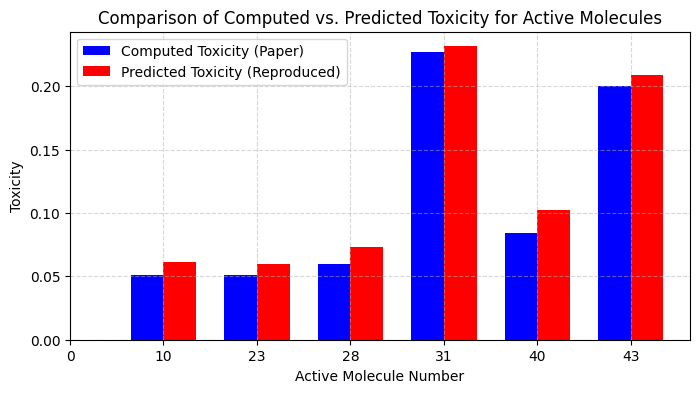

In [ ]:
# plot the predicted toxicity for the 6 active molecules

active_ids = [10, 23, 28, 31, 40, 43]
active_molecules = df[df['compound_id'].isin(active_ids)]

paper_toxicity = active_molecules["CT_TOX"]
predicted_toxicity = active_molecules["chemprop_rdkit_ensemble_preds"]

num_active_molecules = len(active_molecules)
molecule_numbers = np.arange(1, num_active_molecules + 1)
#compound_ids = active_molecules['compound_id'].values
compound_ids = np.insert(active_molecules['compound_id'].values, 0, 0)
plt.figure(figsize=(8, 4))
bar_width = 0.35
r1 = molecule_numbers - bar_width / 2
r2 = molecule_numbers + bar_width / 2

plt.bar(r1, paper_toxicity, color='b', width=bar_width, label="Computed Toxicity (Paper)")
plt.bar(r2, predicted_toxicity, color='r', width=bar_width, label="Predicted Toxicity (Reproduced)")

plt.xlabel('Active Molecule Number')
plt.ylabel('Toxicity')
plt.title('Comparison of Computed vs. Predicted Toxicity for Active Molecules')
plt.xticks(np.arange(num_active_molecules+1), compound_ids)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()